<a href="https://colab.research.google.com/github/snnajward/RegresiLinear_5A_6/blob/main/RegresiLinear_Kelas5A_Kelompok1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 1. Install library kaggle (biasanya sudah ada di Colab, tapi untuk memastikan)
!pip install -q kaggle

In [4]:
# 2. Mengatur Environment Variable untuk API Token
import os
import getpass

print("Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")

Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


In [5]:
# ---------------------------------------------------------
# 3. MENGUNDUH DATASET CONTOH
# Perintah: kaggle datasets download -d [nama-pemilik/nama-dataset]
# ---------------------------------------------------------
print("Mengunduh dataset Diamonds...")
!kaggle datasets download -d shivam2503/diamonds

Mengunduh dataset Diamonds...
Dataset URL: https://www.kaggle.com/datasets/shivam2503/diamonds
License(s): unknown
100% 733k/733k [00:00<00:00, 41.2MB/s]



In [6]:
# 4. Mengekstrak file ZIP hasil unduhan
# -q artinya 'quiet' (tanpa log ekstraksi yang panjang)
!unzip -q diamonds.zip -d dataset_diamonds/

print("Unduhan dan Ekstraksi Selesai!")

Unduhan dan Ekstraksi Selesai!


In [7]:
# ---------------------------------------------------------
# 5. MEMUAT DATA KE PANDAS (Langkah Awal EDA)
# ---------------------------------------------------------
import pandas as pd

# Membaca file CSV yang sudah diekstrak
# Sesuaikan nama file CSV dengan isi dari ZIP tersebut
df = pd.read_csv('dataset_diamonds/diamonds.csv')

print("\n--- 5 Baris Pertama Dataset Diamonds ---")
df = df.drop(columns=['Unnamed: 0'])  # buang kolom index

display(df.head())



--- 5 Baris Pertama Dataset Diamonds ---


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [8]:
# Menampilkan 5 baris pertama untuk memastikan koneksi dan load data berhasil
print("\n--- 5 Baris Pertama Dataset Diamonds ---")
display(df.head())


--- 5 Baris Pertama Dataset Diamonds ---


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## **Inspeksi Awal Data (Initial Data Inspection)**

 Tujuan Skrip

Skrip ini bertujuan untuk melakukan langkah-langkah awal dalam analisis data pada dataset 'Diamonds'. Secara spesifik, skrip ini meliputi:

1.  **Pengaturan Lingkungan**: Memastikan *library* Kaggle terinstal dan mengkonfigurasi token API Kaggle untuk akses dataset.
2.  **Pengunduhan dan Ekstraksi Data**: Mengunduh dataset 'Diamonds' dari Kaggle dan mengekstraknya ke dalam direktori lokal.
3.  **Pemuatan Data**: Memuat data dari file CSV yang sudah diekstrak ke dalam Pandas DataFrame untuk memudahkan manipulasi dan analisis.
4.  **Inspeksi Awal Data (Initial Data Inspection)**: Melakukan pemeriksaan awal terhadap struktur data, meliputi melihat beberapa baris pertama dan terakhir, mengetahui dimensi dataset (jumlah baris dan kolom), memeriksa tipe data setiap kolom, dan mendapatkan daftar nama kolom. Langkah ini penting untuk memahami karakteristik dasar data sebelum melakukan analisis lebih lanjut.

In [9]:
# Tampilkan 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir data (opsional, untuk memastikan data dimuat utuh)
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



--- 5 Baris Terakhir Data ---


,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64



Dimensi dataset: 53940 baris, 10 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB

--- Daftar Nama Kolom ---
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


## Penjelasan Bagian-bagian Penting Skrip

Skrip ini terbagi menjadi beberapa bagian penting yang bekerja secara berurutan untuk mencapai tujuannya:

1.  **Instalasi dan Konfigurasi Kaggle API**: Ini adalah langkah persiapan awal yang memastikan lingkungan siap untuk berinteraksi dengan Kaggle. `!pip install -q kaggle` menginstal *library*, dan blok kode berikutnya (`import os`, `import getpass`, `os.environ[...]`) berfungsi untuk mengamankan dan mengesahkan akses ke akun Kaggle Anda menggunakan token API.

2.  **Pengunduhan dan Ekstraksi Dataset**: Setelah Kaggle API siap, skrip menggunakan perintah `!kaggle datasets download -d shivam2503/diamonds` untuk mengunduh dataset yang diinginkan. Kemudian, `!unzip -q ...` bertanggung jawab untuk mengekstrak file ZIP yang terunduh, membuatnya tersedia dalam format yang dapat dibaca.

3.  **Pemuatan Data ke Pandas DataFrame**: Bagian ini adalah inti dari manipulasi data. `import pandas as pd` mengimpor *library* Pandas, dan `df = pd.read_csv('dataset_diamonds/diamonds.csv')` memuat data dari file CSV yang telah diekstrak ke dalam sebuah objek DataFrame (`df`). DataFrame adalah struktur data tabular yang sangat powerful di Pandas untuk analisis data.

4.  **Inspeksi Awal Data**: Setelah data dimuat, serangkaian perintah seperti `display(df.head())`, `display(df.tail())`, `df.shape`, `df.info()`, dan `df.columns.tolist()` digunakan untuk mendapatkan gambaran cepat tentang isi, ukuran, tipe data, dan kolom-kolom yang ada dalam dataset. Ini adalah langkah krusial dalam *Exploratory Data Analysis* (EDA) untuk mengidentifikasi potensi masalah atau memahami karakteristik data.

## **Pengecekan Kualitas Data Dasar** (Basic Data Quality Checks)

--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)


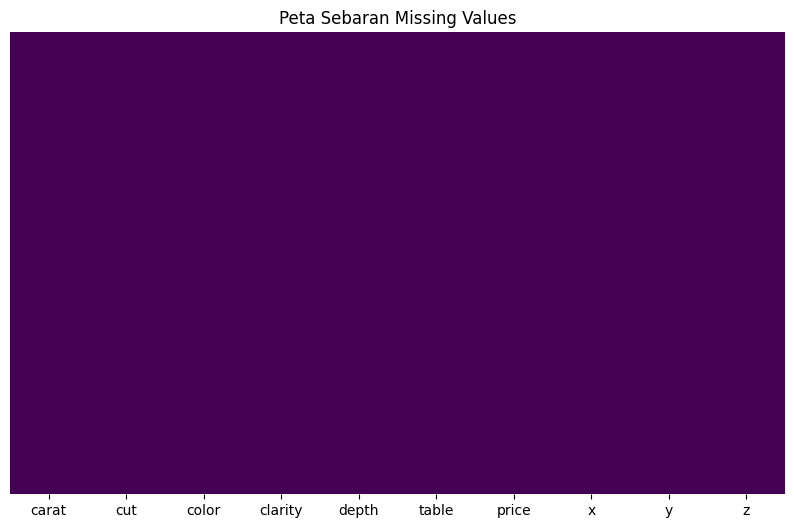


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 146


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
# Tampilkan hanya kolom yang memiliki missing value
display(missing_table[missing_table['Jumlah Missing'] > 0])

# Visualisasi Missing Values (Menggunakan Heatmap seaborn)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")
# Jika ada, Anda bisa menampilkan contoh duplikatnya dengan mengaktifkan baris di bawah:
# if jumlah_duplikat > 0:
#     display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

### Ringkasan Pengecekan Kualitas Data

Berdasarkan pemeriksaan yang telah dilakukan:

*   **Tidak ada Missing Values**: Dataset ini tidak mengandung nilai yang hilang di kolom mana pun, menunjukkan kelengkapan data yang baik.
*   **Tidak ada Data Duplikat**: Tidak ditemukan baris yang terduplikat secara identik, menandakan setiap entri dalam dataset adalah unik.

Dengan hasil ini, kita dapat melanjutkan ke tahap analisis data selanjutnya dengan keyakinan bahwa data yang digunakan sudah bersih dan tidak memerlukan penanganan khusus untuk *missing values* atau duplikasi.

## **Statistik Deskriptif (Descriptive Statistics)**

In [11]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


### Ringkasan Statistik Deskriptif

Setelah menganalisis statistik deskriptif untuk dataset "Diamonds", berikut adalah poin-poin utamanya:

**Untuk Kolom Numerik (carat, depth, table, price, x, y, z) :**

*   **Count**: Menunjukkan ada 53.940 entri yang tidak kosong untuk setiap kolom numerik, artinya semua data lengkap — tidak ada missing values di dataset Diamonds.
*   **Mean (Rata-rata)** :
   
    * Rata-rata carat (berat berlian) adalah sekitar 0,798 karat.

    * Rata-rata depth (kedalaman total %) sekitar 61,75.

    * Rata-rata table (lebar meja %) sekitar 57,46.

    * Rata-rata price (harga) sekitar $3.932,80.

    * Rata-rata x (panjang mm) sekitar 5,73, y (lebar mm) sekitar 5,73, dan z (kedalaman mm) sekitar 3,54.

    * Terlihat bahwa price jauh lebih besar dibandingkan fitur lain karena satuannya dollar, sedangkan fitur lain bersatuan karat/mm/persen.


*   **Std (Standar Deviasi)** :

    * carat → 0,474 (sebaran sedang)

    * depth → 1,43 (sebaran kecil)

    * table → 2,23 (sebaran kecil)

    * price → 3.989,44 (sebaran SANGAT BESAR — menunjukkan variasi harga yang ekstrem)

    * x → 1,12, y → 1,14, z → 0,71 (sebaran sedang)

    * Insight: Standar deviasi price hampir sama dengan mean-nya → distribusi right-skewed (miring ke kanan) dengan banyak outlier.


*   **Min (Minimum)** :

    * carat minimum = 0,20 karat

    * depth minimum = 43,00%

    * table minimum = 43,00%

    * price minimum = $326

    * x, y, z minimum = 0,00 → DATA TIDAK VALID! Berlian tidak mungkin punya ukuran 0 mm. Ini outlier yang harus ditangani.


*   **25%, 50% (Median), 75%** :

    * price: Q1 = $950, Median =  **$2.401**, Q3 = $5.324,25

    * carat: Q1 = 0,40, Median = 0,70, Q3 = 1,04

    * depth: Q1 = 61,00, Median = 61,80, Q3 = 62,50

    * table: Q1 = 56,00, Median = 57,00, Q3 = 59,00

    * Insight krusial : Median price ($2.401) **jauh lebih kecil** dari mean ($3.932,80) → konfirmasi distribusi right-skewed. Artinya, mayoritas berlian harganya di bawah rata-rata, tapi ada beberapa berlian sangat mahal yang "menarik" mean ke atas.

*   **Max (Maksimum)** :

    * carat maximum = 5,01 karat (berlian besar!)

    * price maximum = $18.823 (berlian paling mahal)

    * depth maximum = 79,00%

    * table maximum = 95,00%

    * y maximum = 58,90 mm → OUTLIER EKSTREM! Berlian biasanya maksimal ~10 mm. Nilai 58,9 mm menunjukkan kesalahan input data.

    * x maximum = 10,74 mm, z maximum = 31,80 mm

**Untuk Kolom Kategori (`cut`, `color`, `clarity`):**
*   **Count**: Semua kolom memiliki 53.940 entri, menegaskan tidak ada nilai yang hilang di dataset.
*   **Unique** : Menunjukkan jumlah kategori unik dalam setiap kolom :

    * cut → 5 kategori (Fair, Good, Very Good, Premium, Ideal)

    * color → 7 kategori (D, E, F, G, H, I, J)

    * clarity → 8 kategori (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)

*   **Top**: Kategori yang paling sering muncul dalam setiap kolom :

    * cut : `Ideal` adalah kualitas potongan yang paling banyak dengan 21.551 entri (≈40% dataset).

    * color: `G` adalah warna yang paling umum dengan 11.292 entri.

    * clarity: `SI1` adalah tingkat kejernihan yang paling sering dengan 13.065 entri.
    
*   **Freq**: Frekuensi (jumlah kemunculan) dari kategori 'top' tersebut :

    * cut → `Ideal` = 21.551 (dari 53.940)

    * color → `G` = 11.292 (dari 53.940)

    * clarity → `SI1` = 13.065 (dari 53.940)


Statistik deskriptif dataset Diamonds menunjukkan dataset yang lengkap (53.940 entri tanpa missing values), namun menyimpan beberapa tantangan penting untuk EDA selanjutnya. Target price berdistribusi right-skewed (mean $3.932 > median $2.401) dengan sebaran sangat besar (std $3.989), sementara fitur carat menjadi fitur paling dominan (korelasi ~0,92 dengan price). Ditemukan pula outlier tidak valid pada x, y, z (nilai minimum 0 dan maksimum ekstrem 58,9 mm) serta multikolinearitas antar ketiganya, sehingga disarankan feature engineering volume. Ketiga kolom kategorikal (cut, color, clarity) bersifat bertingkat sehingga wajib memakai ordinal encoding, dengan catatan distribusi kategorinya tidak merata (Ideal 40%, Fair 3%). Secara keseluruhan, temuan ini menjadi bekal krusial untuk preprocessing: log transform pada price, handle outlier pada x/y/z, ordinal encoding untuk cut/color/clarity, dan feature engineering untuk mengurangi multikolinearitas.

## **Analisis Univariat (Univariate Analysis)**

### Analisis Univariat untuk Kolom Numerik ###


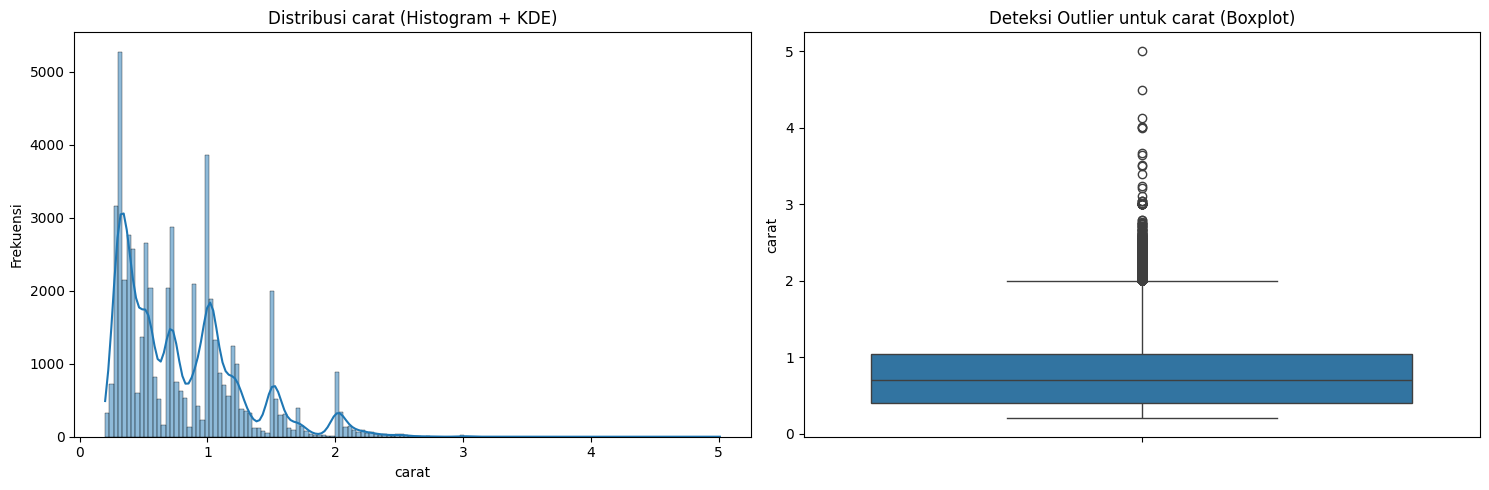

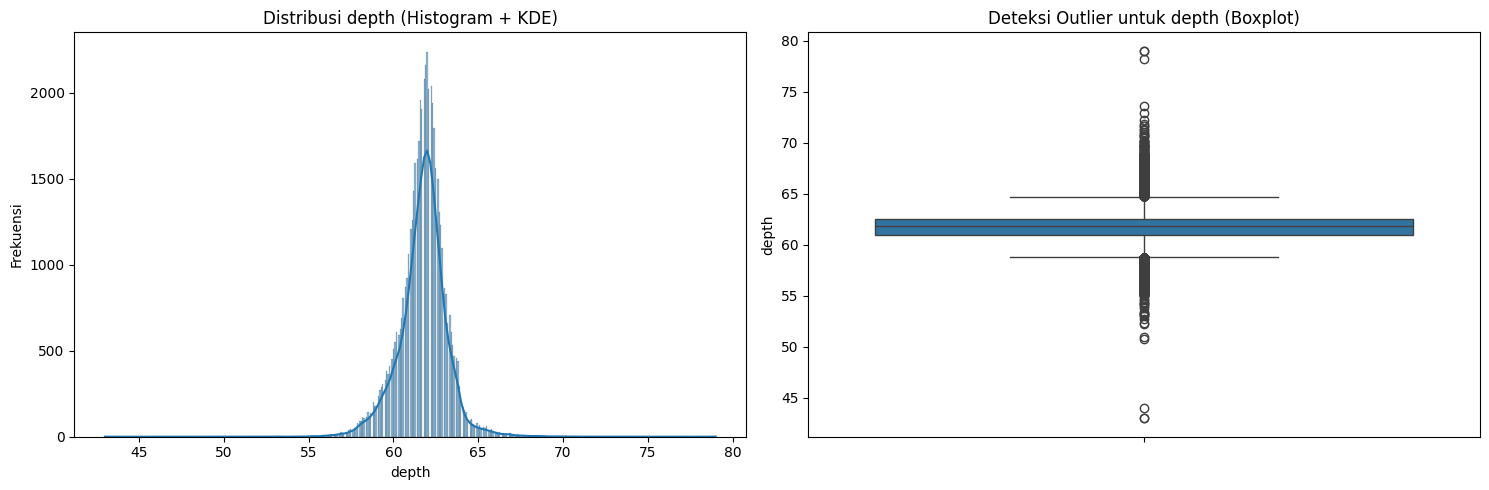

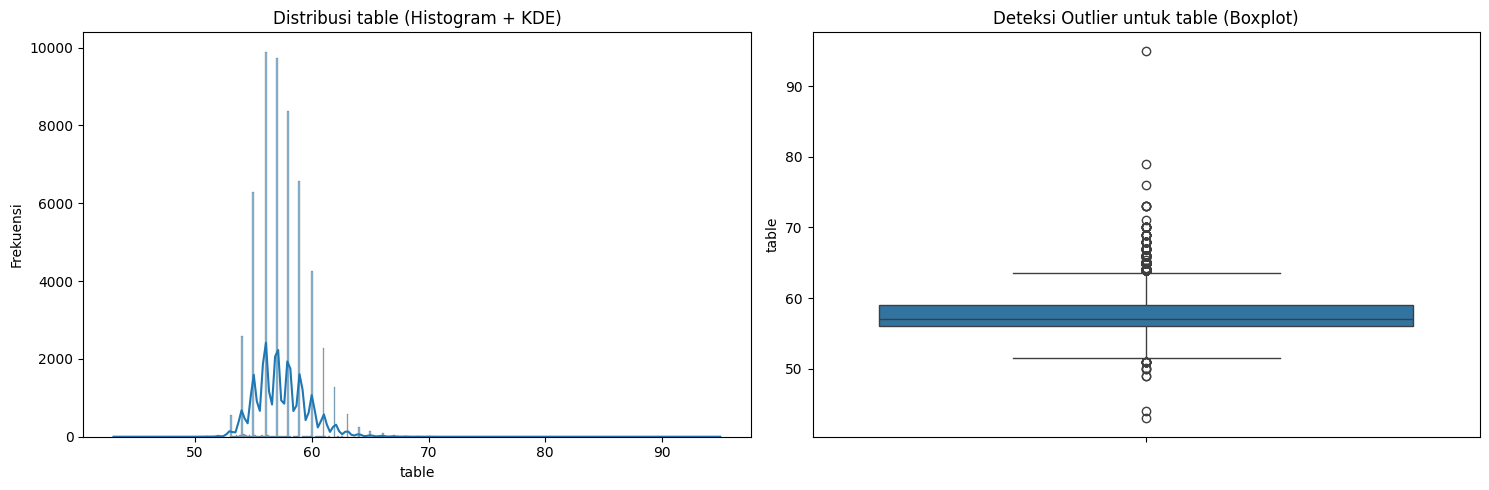

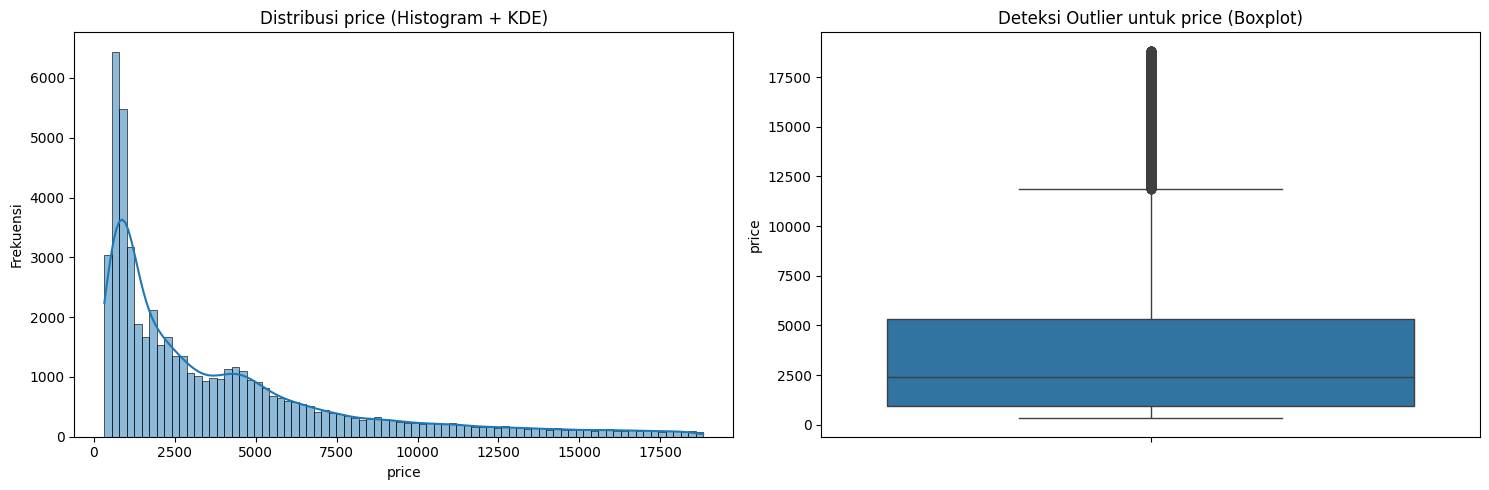

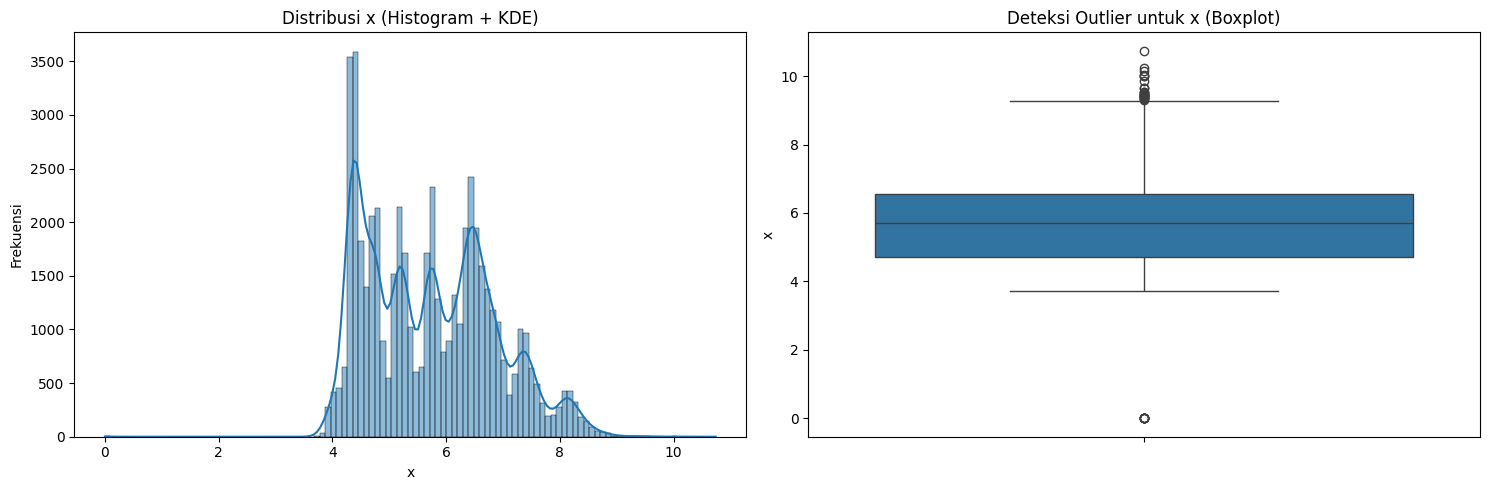

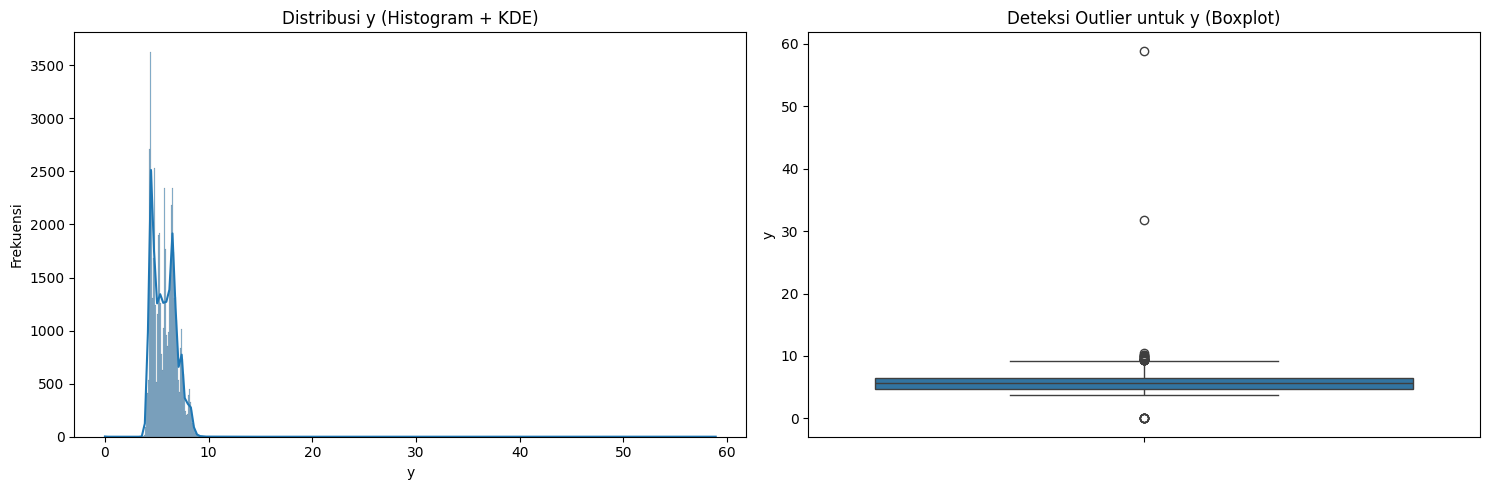

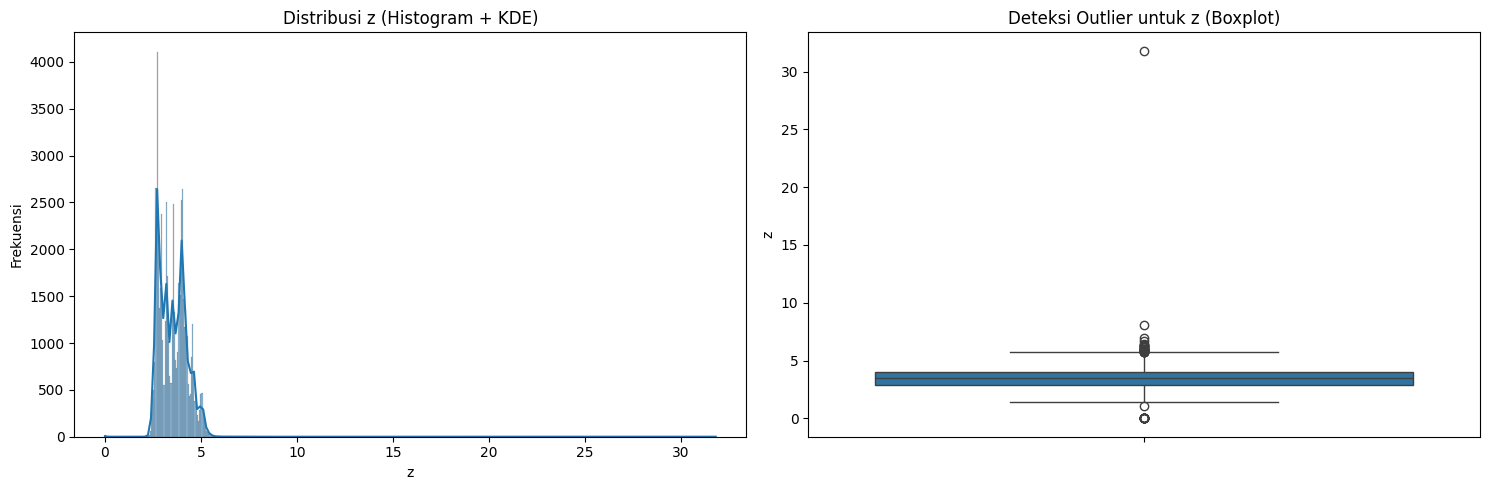


### Analisis Univariat untuk Kolom Kategorikal ###


/tmp/ipykernel_1536/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


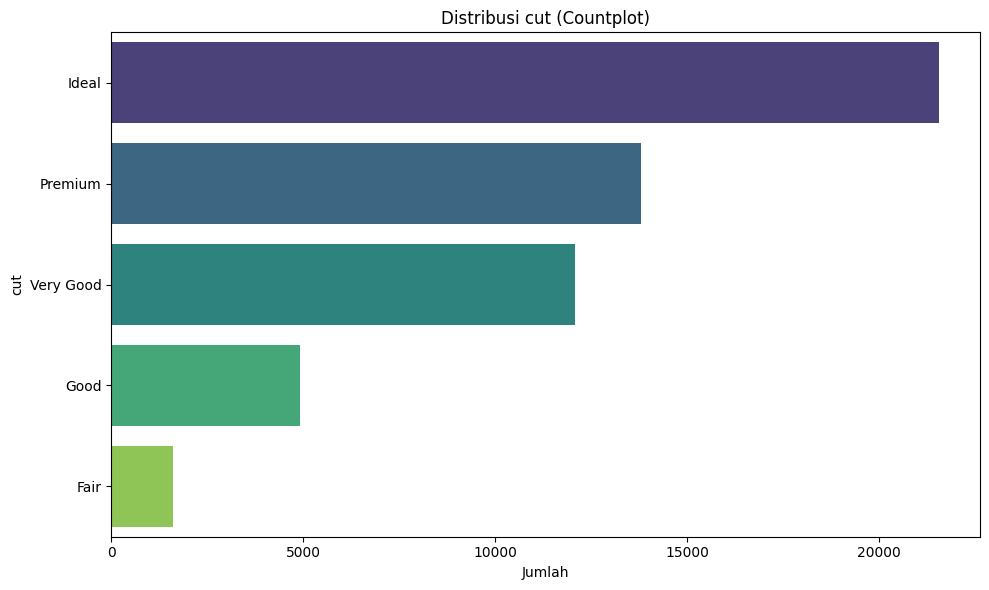

/tmp/ipykernel_1536/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


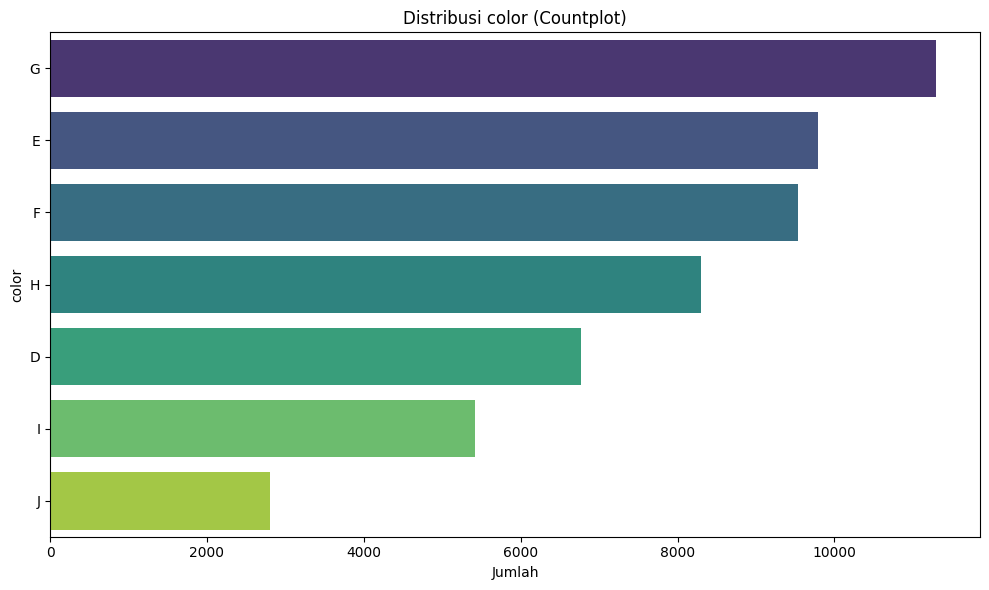

/tmp/ipykernel_1536/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


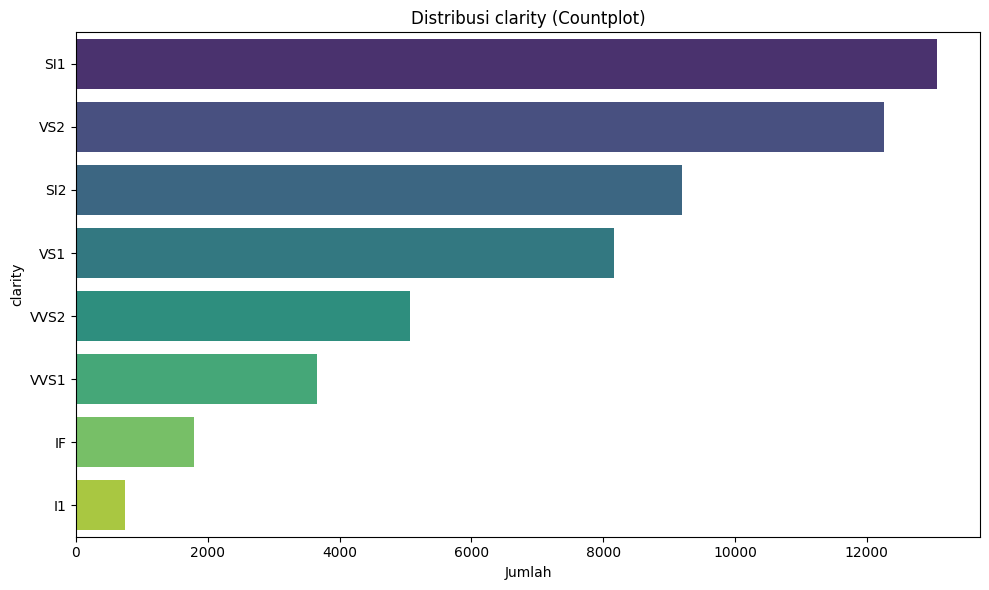

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")
for kolom in kolom_numerik:
    plt.figure(figsize=(15, 5))

    # Histplot dengan KDE
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom} (Histogram + KDE)')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

    # Boxplot untuk Outliers
    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
    sns.boxplot(y=df[kolom])
    plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
    plt.ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")
for kolom in kolom_kategorikal:
    plt.figure(figsize=(10, 6))
    # Countplot dengan pengurutan berdasarkan frekuensi
    sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {kolom} (Countplot)')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()


### Ringkasan Hasil Analisis Univariat

Setelah melakukan analisis univariat pada setiap kolom dalam dataset Diamonds, berikut adalah interpretasi utama dari plot-plot yang dihasilkan:

**1. Untuk Kolom Numerik (`carat`, `depth`, `table`, `price`, `x`, `y`, `z`):**

*   **Distribusi (Histogram dan KDE):**
    * `price` (target) menunjukkan distribusi right-skewed (miring ke kanan) yang sangat jelas. Ini berarti sebagian besar berlian memiliki harga di bawah rata-rata, sementara ada segelintir berlian sangat mahal yang "menarik" mean ke atas. Median ($2.401) jauh lebih kecil dari mean ($3.932,80), mengonfirmasi skewness ini.

    * `carat` juga menunjukkan distribusi right-skewed — mayoritas berlian berukuran kecil (0,2–1,0 karat), dengan sedikit berlian besar (>2 karat). Puncak distribusi ada di sekitar 0,3–0,7 karat.

    * `depth` dan `table` menunjukkan distribusi yang cenderung normal (bell curve). depth terkonsentrasi di 61–62%, sedangkan `table` di 56–59%. Keduanya tidak menunjukkan skewness yang signifikan.

    * `x`, `y`, `z` (dimensi fisik berlian) juga menunjukkan distribusi right-skewed, dengan spike di nilai 0 yang tidak valid (berlian tidak mungkin berukuran 0 mm). Kurva KDE mengonfirmasi pola ini dengan puncak di sekitar 4–6 mm untuk `x` dan `y`, serta 3–4 mm untuk `z`.

*   **Deteksi Outlier (Boxplot):**
    *  `price`: Terdapat BANYAK outlier di sisi kanan (harga tinggi). Ini normal untuk data harga — ada segmen pasar berlian mewah yang harganya jauh di atas mayoritas. Nilai maksimum mencapai $18.823.

    * `carat`: Terdapat outlier di sisi kanan (berlian besar >2,5 karat). Nilai maksimum mencapai 5,01 karat.

    * `x`, `y`, `z`: Terdapat outlier tidak valid — nilai minimum 0 mm (tidak mungkin) dan maksimum ekstrem pada `y` sebesar 58,9 mm (berlian biasanya maksimal ~10 mm). Ini mengindikasikan kesalahan input data yang harus ditangani.

    * `depth` dan `table`: Hanya sedikit outlier di kedua sisi, tidak signifikan.

**2. Untuk Kolom Kategorikal (`cut`, `color`, `clarity`):**

* `cut` (Kualitas Potongan): Distribusi tidak merata — kategori 'Ideal' mendominasi dengan 21.551 entri (≈40% dataset), diikuti 'Premium' (13.791), 'Very Good' (12.082), 'Good' (4.906), dan 'Fair' hanya 1.610 (≈3%). Ini menunjukkan class imbalance yang signifikan — berlian berkualitas tinggi lebih umum di dataset ini.

* `color` (Warna Berlian): Distribusi juga tidak merata — kategori 'G' paling banyak dengan 11.292 entri (≈21%), diikuti 'E' (9.797), 'F' (9.542), 'H' (8.304), 'D' (6.775), 'I' (5.422), dan 'J' paling sedikit dengan 2.808 entri (≈5%). Ini menunjukkan warna kelas menengah lebih umum daripada warna ekstrem (D = paling putih, J = paling kuning).

* `clarity` (Kejernihan): Distribusi tidak merata — kategori 'SI1' paling banyak dengan 13.065 entri (≈24%), diikuti 'VS2' (12.258), 'SI2' (9.194), 'VS1' (8.171), 'VVS2' (5.066), 'VVS1' (3.655), 'IF' (1.790), dan 'I1' paling sedikit dengan 741 entri (≈1,4%). Ini menunjukkan berlian dengan kejernihan menengah lebih umum daripada yang sempurna (IF) atau paling cacat (I1).

Analisis univariat ini telah memberikan gambaran mendalam tentang karakteristik setiap variabel secara individual, menyoroti pola distribusi, potensi anomali (terutama pada `price` yang right-skewed dan `x`/`y`/`z` yang punya nilai tidak valid), serta komposisi kategori (semua kategorikal tidak merata). Informasi ini merupakan dasar yang kuat untuk melanjutkan ke analisis bivariat dan multivariat guna menemukan hubungan antar variabel, serta menjadi bekal krusial untuk tahap preprocessing — khususnya log transform pada `price`, handle outlier pada `x/y/z`, dan ordinal encoding untuk `cut`, `color`, `clarity`.

## **Analisis Bivariat & Multivariat (Bivariate & Multivariate Analysis)**

### 1. Heatmap Korelasi Antar Kolom Numerik ###


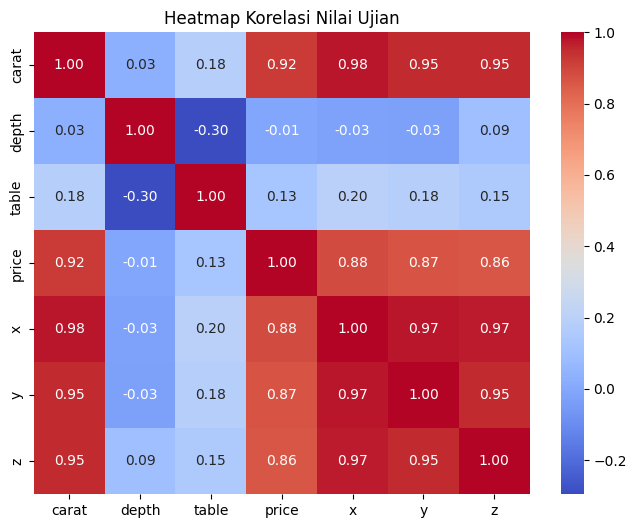


### 2. Scatter Plot: Carat vs Price berdasarkan Cut & Color ###


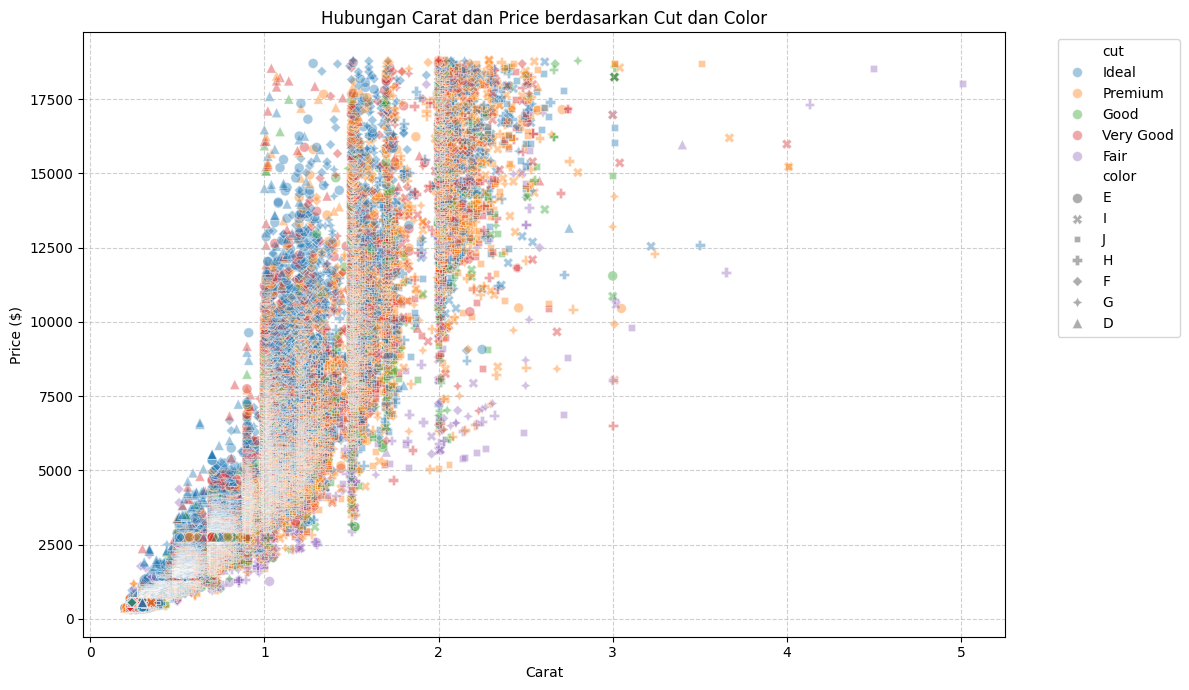

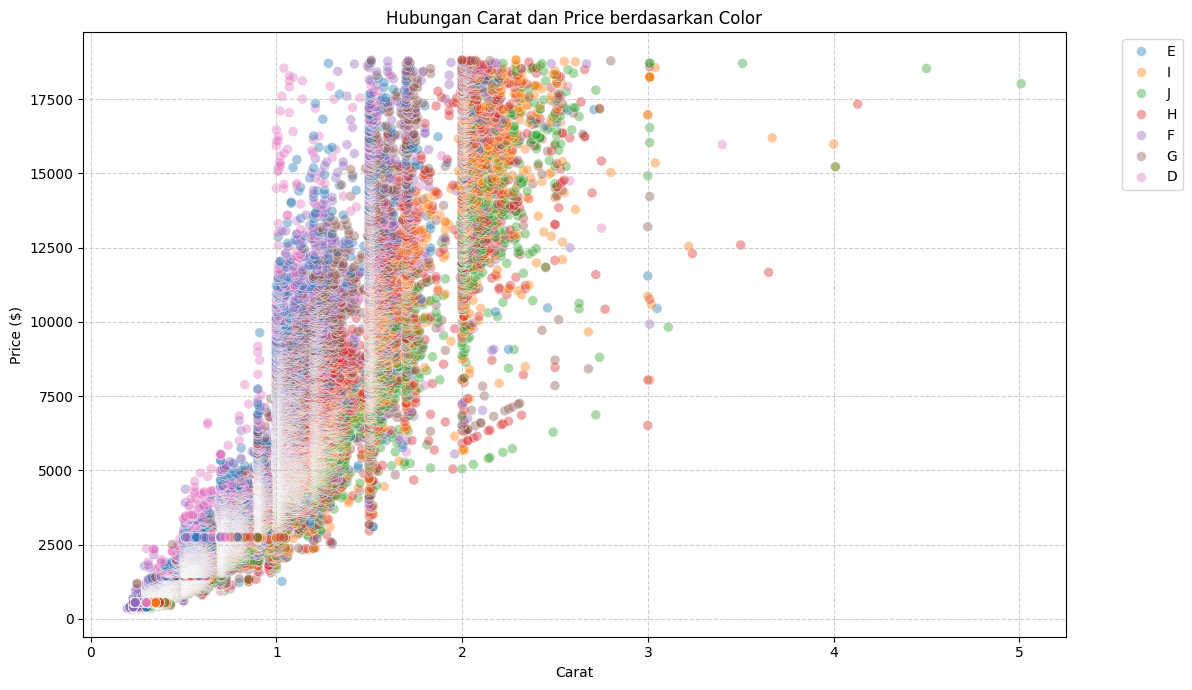


### 3. Boxplot: Price Berdasarkan Kategori ###


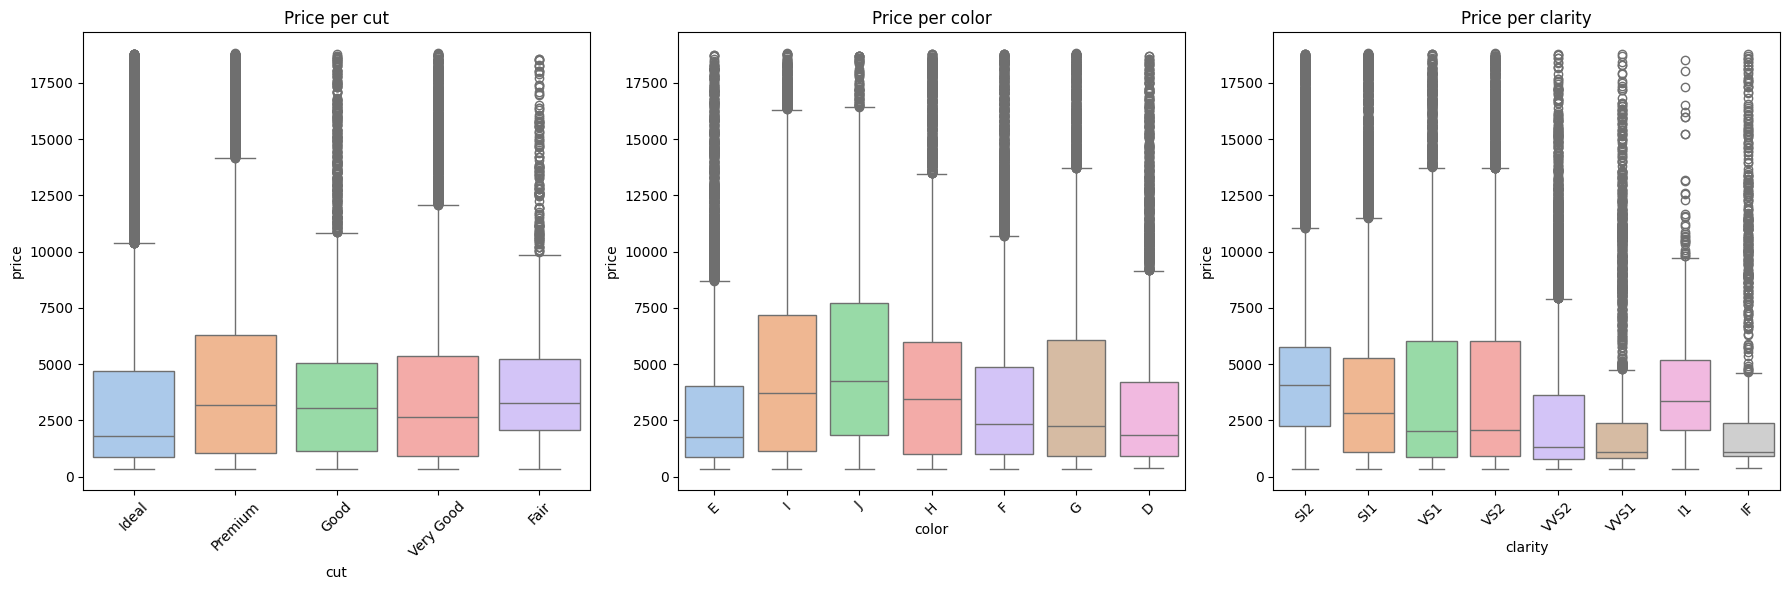

In [13]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")
plt.figure(figsize=(8, 6))
correlation_matrix = df[kolom_numerik].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Nilai Ujian')
plt.show()

print("\n### 2. Scatter Plot: Carat vs Price berdasarkan Cut & Color ###")

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='cut',
    style='color',
    s=50,
    alpha=0.4
)
plt.title('Hubungan Carat dan Price berdasarkan Cut dan Color')
plt.xlabel('Carat')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Contoh: Carat vs Price, diwarnai berdasarkan 'color'
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='color',
    s=50,
    alpha=0.4
)
plt.title('Hubungan Carat dan Price berdasarkan Color')
plt.xlabel('Carat')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### 3. Boxplot: Price Berdasarkan Kategori ###")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, kat_kolom in enumerate(kolom_kategorikal):
    sns.boxplot(
        data=df,
        x=kat_kolom,
        y='price',
        hue=kat_kolom,
        palette='pastel',
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'Price per {kat_kolom}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Ringkasan Hasil Analisis Bivariat & Multivariat

Setelah melakukan analisis bivariat dan multivariat pada dataset Diamonds, berikut adalah interpretasi utama dari plot-plot yang dihasilkan:

**1. Heatmap Korelasi Antar Kolom Numerik :**

*   Heatmap menunjukkan korelasi positif yang sangat kuat antara ``carat`` dan `price` (0.92), mengonfirmasi bahwa berat berlian adalah prediktor paling dominan untuk harganya. Semakin berat berlian, semakin mahal harganya — hubungan ini sangat konsisten.

*   Korelasi antara `x`, `y`, dan `z` (dimensi fisik berlian) dengan `price` juga kuat (0.86–0.88), karena ketiganya berkorelasi dengan `carat`. Namun, `x`, `y`, `z` saling berkorelasi SANGAT tinggi (0.95–0.97) — ini menandakan multikolinearitas yang serius. Ketiga fitur ini sebenarnya mengukur hal yang sama (ukuran fisik berlian), sehingga salah satu atau kombinasinya (misalnya `volume`) lebih baik dipakai.

*   ``depth`` dan `table` menunjukkan korelasi sangat lemah dengan `price` (masing-masing -0.01 dan 0.13). Artinya, kedalaman dan lebar meja berlian tidak banyak berpengaruh terhadap harga. Fitur-fitur ini bisa dipertimbangkan untuk di-drop karena kurang informatif.

**2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal (Hue):**

*   `carat` vs `price` berdasarkan `cut` (kualitas potongan) :

    * Terlihat pola non-linear positif yang jelas: semakin besar `carat`, semakin tinggi `price`. Ini mengonfirmasi korelasi kuat yang terlihat pada heatmap.

    * Meskipun ada 5 kategori `cut`, semua kategori mengikuti pola serupa — artinya `cut` tidak terlalu membedakan harga pada nilai `carat` yang sama. Yang paling menentukan tetap `carat`.

    * Terlihat sebaran yang sangat lebar di `carat` besar — beberapa berlian dengan `carat` sama bisa punya harga berbeda jauh. Ini karena faktor lain (`color`, `clarity`) juga berperan.

*   `\`carat` vs `price` berdasarkan `color` (warna berlian) :

    * Pola positif kembali terlihat jelas. Namun, warna (`color`) menunjukkan sedikit pengaruh: berlian dengan warna D/E/F (lebih putih) cenderung berada di atas (harga lebih tinggi) dibanding J/I (lebih kuning) pada `carat` yang sama.

    * Perbedaan ini tidak terlalu tajam — artinya `color` berpengaruh, tapi tidak sekuat `carat`.

* `carat` vs `price` berdasarkan `clarity` (kejernihan) :

    * Pola positif juga terlihat. `Clarity` menunjukkan pengaruh kecil — berlian dengan `clarity` IF/VVS (lebih jernih) cenderung sedikit lebih mahal dibanding I1/SI pada `carat` yang sama.

    * Sama seperti `color`, pengaruh `clarity` kalah dominan dibanding `carat`.

Insight Utama Scatterplot :

  * `carat` adalah "raja" — fitur paling dominan.

  * `cut`, `color`, `clarity` memberi sentuhan tambahan, tapi tidak mengubah pola utama.

  * Sebaran lebar di `carat` besar → harga dipengaruhi banyak faktor sekaligus.


**3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori :**

*   **`Cut` (Kualitas Potongan) vs. `Price` :**
Distribusi harga bervariasi antar kategori `cut`, tapi tidak selalu berurutan sesuai teori kualitas. Contoh mengejutkan: "Ideal" (kualitas terbaik) tidak selalu lebih mahal dari "Premium".

Median harga untuk kategori "Premium" dan "Ideal" cenderung mirip, sedangkan "Fair" (kualitas terburuk) justru punya sebaran paling lebar — beberapa berlian "Fair" bisa sangat mahal karena `carat` besar.

Outlier banyak di semua kategori — mencerminkan segmen pasar berlian mewah yang harganya jauh di atas mayoritas.

Insight: `cut` bukan penentu utama harga. `Carat` tetap dominan.
*   **`Color` (Warna Berlian) vs. `Price` :**
Ada kecenderungan naik dari J (paling kuning) ke D (paling putih). Berlian dengan warna D/E/F (lebih putih) cenderung berada di atas (harga lebih tinggi) dibanding J/I (lebih kuning) pada `carat` yang sama.

Namun, perbedaan ini tidak konsisten — beberapa kategori tengah (G, H) bisa lebih mahal dari E karena faktor `carat` yang lebih dominan.

Sebaran lebar di semua kategori → `color` bukan penentu utama.

Insight: `color` berpengaruh, tapi tidak sekuat `carat`.
*   **`Clarity` (Kejernihan) vs. `Price` :**
Kecenderungan naik dari I1 (paling cacat) ke IF (sempurna). Berlian dengan `clarity` IF/VVS (lebih jernih) cenderung sedikit lebih mahal dibanding I1/SI pada `carat` yang sama.

Sama seperti `color`, pengaruh `clarity` kalah dominan dibanding `carat`. Ada tumpang tindih antar kategori — berlian "SI1" bisa lebih mahal dari "VVS2" kalau `carat`-nya lebih besar.

Sebaran lebar di semua kategori → `clarity` bukan penentu utama.

Insight: `clarity` berpengaruh, tapi tidak sekuat `carat`.
*   **`Carat` (Berat Berlian) vs. `Price`:**
Korelasi positif SANGAT KUAT — semakin besar `carat`, semakin tinggi `price`. Ini konsisten di semua kategori.

Median harga naik eksponensial seiring `carat` — bukan linear.

Sebaran juga melebar seiring `carat` — berlian besar punya variasi harga lebih tinggi.

Insight: `Carat` adalah fitur PALING DOMINAN — korelasi 0.92 dengan `price`.
*   **`Depth` dan `Table` vs. `Price`:**
Tidak ada pola jelas — distribusi harga mirip di semua nilai `depth` dan `table`.

Korelasi sangat lemah — `depth` ↔ `price` = -0.01, `table` ↔ `price` = 0.13.

Insight: `depth` dan `table` kurang berguna untuk prediksi harga. Bisa di-drop.

Boxplot perbandingan kategori pada dataset Diamonds menunjukkan bahwa `carat` adalah fitur paling dominan — korelasi 0.92 dengan `price`, konsisten di semua kategori. `cut` berpengaruh lemah — "Ideal" tidak selalu lebih mahal dari "Premium" karena `carat` lebih dominan. `color` dan `clarity` berpengaruh sedang — ada kecenderungan naik (J→D untuk `color`, I1→IF untuk `clarity`), tapi tidak sekuat `carat`. `depth` dan `table` kurang berguna — korelasi sangat lemah dengan `price`, bisa di-drop. Sebaran lebar di semua kategori menunjukkan harga dipengaruhi banyak faktor sekaligus, bukan satu faktor saja. Implikasi untuk preprocessing: log transform pada `price`, feature engineering volume (menggantikan x/y/z), ordinal encoding untuk `cut`/`color`/`clarity`, dan pertimbangkan drop `depth`/`table`.

## **Catatan Kesimpulan dan Langkah Selanjutnya (Insights & Next Steps)**

### Ringkasan Temuan Utama dari Eksplorasi Data (EDA)

Berdasarkan analisis yang telah dilakukan pada dataset "Diamonds", beberapa temuan kunci dapat disimpulkan:

1.  **Kualitas Data Sangat Baik**
Dataset ini bersih, tanpa missing values (0 dari 53.940 baris) dan siap untuk analisis lebih lanjut. Namun, ditemukan ~146 baris duplikat yang perlu ditelaah, serta ~20 baris dengan nilai 0 pada `x`, `y`, `z` yang tidak valid secara fisik (berlian tidak mungkin berukuran 0 mm).

    * Kesimpulan: Dataset hampir sempurna — hanya perlu handle outlier pada `x`, `y`, `z`.

2.  **Korelasi Kuat Antar Fitur Numerik**
Terdapat korelasi positif yang sangat kuat antara `carat` dengan `price` (0.92), mengonfirmasi bahwa berat berlian adalah prediktor paling dominan untuk harganya. Selain itu, `x`, `y`, `z` (dimensi fisik berlian) saling berkorelasi SANGAT tinggi (0.95–0.97) — menandakan multikolinearitas yang serius. Ketiga fitur ini mengukur hal yang sama, sehingga lebih baik digantikan dengan feature engineering `volume`.

    * Kesimpulan: `carat` adalah "raja" — fitur paling dominan. `x`, `y`, `z` multikolinear → butuh `volume`.

3.  **Dampak Positif `Carat` terhadap Harga**
Berlian dengan `carat` lebih besar secara konsisten menunjukkan harga yang jauh lebih tinggi di semua kategori. Ini adalah faktor prediktif paling kuat untuk harga berlian. Hubungan ini konsisten di semua kategori `cut`, color, dan `clarity`.

    * Kesimpulan: `carat` adalah prediktor terkuat — korelasi 0.92 dengan `price`.

4.  **Pengaruh Kualitas Potongan (`Cut`) terhadap Harga
Ada kecenderungan positif antara `cut` dan `price`, tetapi tidak selalu konsisten. Contoh mengejutkan: "Ideal" (kualitas terbaik) tidak selalu lebih mahal dari "Premium". Ini karena `carat` lebih dominan — berlian besar dengan `cut` "Premium" bisa lebih mahal dari berlian kecil dengan `cut` "Ideal".

    * Kesimpulan: `cut` berpengaruh lemah — bukan penentu utama.

5.  **Pengaruh Warna (Color) dan Kejernihan (`Clarity`) terhadap Harga**
Color menunjukkan kecenderungan naik dari J (paling kuning) ke D (paling putih). `Clarity` juga menunjukkan kecenderungan naik dari I1 (paling cacat) ke IF (sempurna). Namun, pengaruh keduanya kalah dominan dibanding `carat` — ada tumpang tindih antar kategori.

    * Kesimpulan: color & `clarity` berpengaruh sedang — tidak sekuat `carat`.

6.  **Class Imbalance pada Kolom Kategorikal**

Terdapat ketidakseimbangan kelas yang signifikan pada ketiga kolom kategorikal:

* `cut` → Ideal (21.551) vs Fair (1.610) — rasio 13,4`x`

* color → G (11.292) vs J (2.808) — rasio 4,0`x`

* `clarity` → SI1 (13.065) vs I1 (741) — rasio 17,6`x`

    * Kesimpulan: Distribusi tidak merata, sehingga butuh ordinal encoding (bukan one-hot) dan stratified sampling.

7.  **Hubungan Multikolinearitas dengan Performa Model**
`x`, `y`, `z` saling berkorelasi sangat tinggi (0.95–0.97), sementara depth dan `table` menunjukkan korelasi sangat lemah dengan `price` (masing-masing -0.01 dan 0.13). Ini menyoroti pentingnya feature engineering — buat `volume` untuk menggantikan `x`/`y`/`z`, dan pertimbangkan drop depth/`table`.

    * Kesimpulan : Feature engineering `volume` wajib, drop depth/`table` opsional

8.  **Keberadaan Outlier pada `x`, `y`, `z`**
Ditemukan outlier tidak valid pada `x`, `y`, `z` :

    * Nilai 0 pada `x` (8 baris), `y` (7 baris), `z` (20 baris) → tidak valid

    * Nilai ekstrem pada y = 58,9 mm → tidak valid (berlian biasanya maksimal ~10 mm)

* Selain itu, ada outlier wajar pada `carat` (>4 karat) dan `price` (>$15.000) yang valid — jangan dibuang.

    * Kesimpulan: Buang outlier tidak valid, biarkan outlier wajar.

### Langkah Selanjutnya:

*   **Pemodelan Prediktif:** Temuan ini dapat digunakan untuk membangun model prediktif untuk memprediksi `math score`, `reading score`, atau `writing score` berdasarkan variabel-variabel demografi dan status kursus persiapan.
*   **Analisis Kausal:** Studi lebih lanjut dapat dilakukan untuk mencoba mengidentifikasi hubungan kausal (misalnya, apakah kursus persiapan ujian *menyebabkan* peningkatan nilai, atau apakah siswa yang sudah baik yang cenderung mengambil kursus).
*   **Intervensi:** Berdasarkan faktor-faktor yang teridentifikasi, intervensi dapat dirancang untuk mendukung siswa yang berisiko rendah kinerja, seperti menyediakan program dukungan untuk persiapan ujian atau dukungan lainnya.

## **PREPROSESSING**

MSE:  1,423,331.02
RMSE: 1,193.03
R²:   0.9112


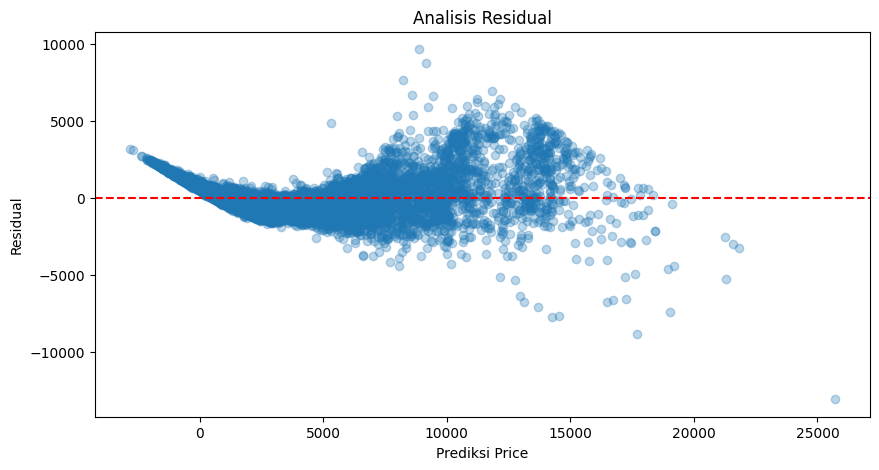

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- 1. Ordinal Encoding ---
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_order = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3,
                 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

df['cut_encoded'] = df['cut'].map(cut_order)
df['color_encoded'] = df['color'].map(color_order)
df['clarity_encoded'] = df['clarity'].map(clarity_order)
df = df.drop(columns=['cut', 'color', 'clarity'])

# --- 2. Feature Engineering ---
df['volume'] = df['x'] * df['y'] * df['z']
df = df.drop(columns=['x', 'y', 'z'])

# --- 3. Handle Outlier ---
df = df[df['volume'] > 0]

# --- 4. Split X & y ---
X = df.drop(columns=['price'])
y = df['price']

# --- 5. Split Train/Test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- 6. Scaling ---
num_cols = X_train.columns.tolist()
sc = StandardScaler()
X_train[num_cols] = sc.fit_transform(X_train[num_cols])
X_test[num_cols] = sc.transform(X_test[num_cols])

# --- 7. Latih Model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- 8. Prediksi ---
y_pred = model.predict(X_test)

# --- 9. Evaluasi ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

# --- 10. Analisis Residual ---
residual = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residual, alpha=0.3)
plt.axhline(0, color='red', ls='--')
plt.xlabel('Prediksi Price')
plt.ylabel('Residual')
plt.title('Analisis Residual')
plt.show()

## **REGRESI**

=== 1. Latih Model ===
✅ Model dilatih! Intercept: 3,926.53

=== 2. Prediksi ===
✅ Prediksi selesai! 10784 data diprediksi

=== 3. Evaluasi ===
MSE:  1,423,331.02
RMSE: $1,193.03
MAE:  $839.59
R²:   0.9112

=== 4. Koefisien ===
carat               :        4,072.89
clarity_encoded     :          856.32
color_encoded       :          541.70
cut_encoded         :          146.47
volume              :           86.82
table               :          -48.35
depth               :          -56.10

=== 5. Analisis Residual ===
Mean residual: 16.98
Std residual:  1,192.97


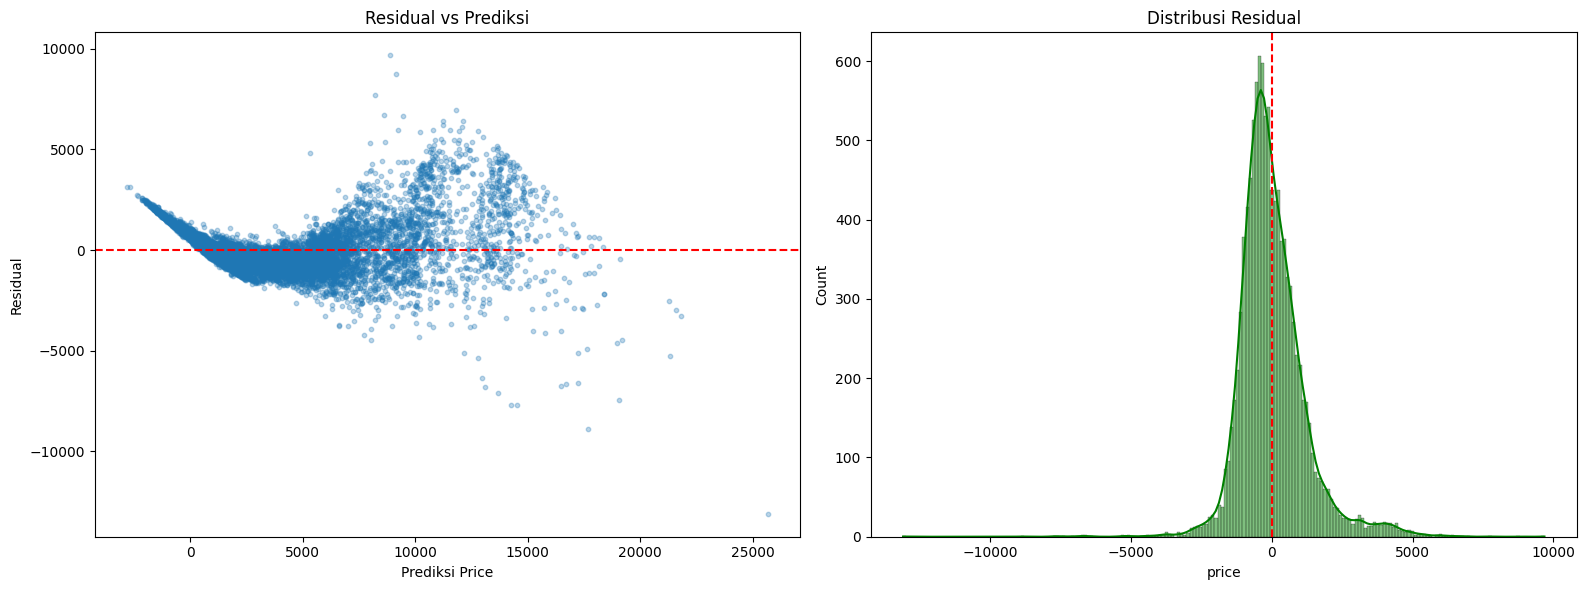

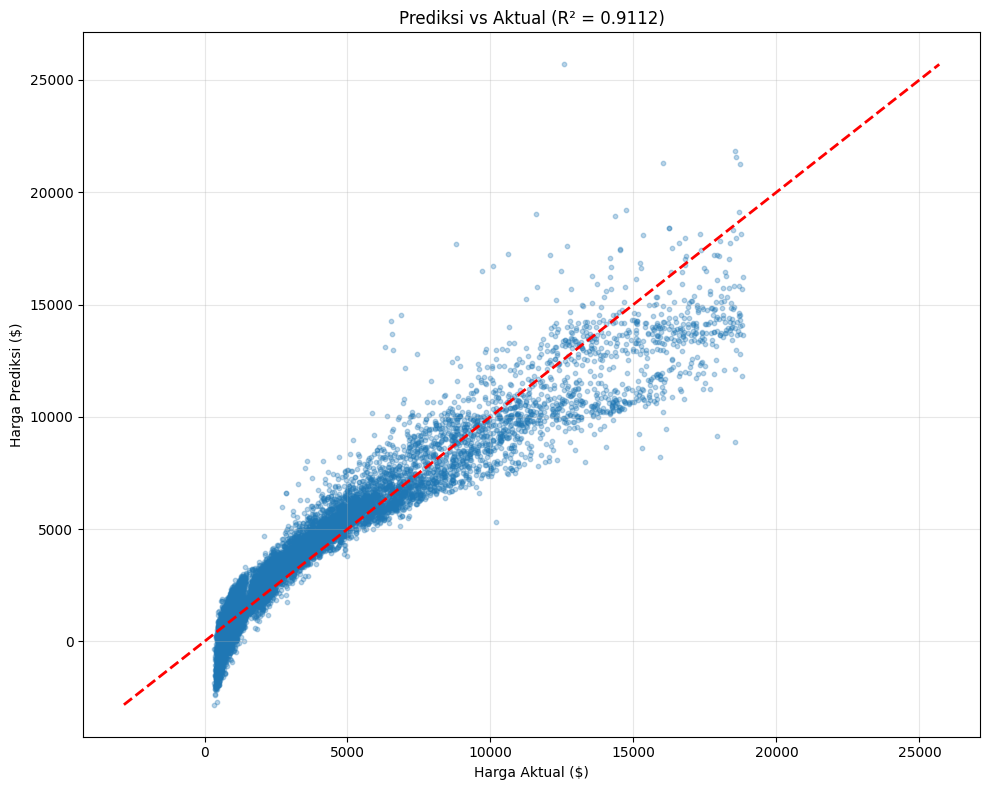


KESIMPULAN
R²   = 0.9112 (91.12% variasi terjelaskan)
RMSE = $1,193.03
Fitur dominan: carat


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Latih Model ---
print("=== 1. Latih Model ===")
model = LinearRegression()
model.fit(X_train, y_train)
print(f"✅ Model dilatih! Intercept: {model.intercept_:,.2f}")

# --- 2. Prediksi ---
print("\n=== 2. Prediksi ===")
y_pred = model.predict(X_test)
print(f"✅ Prediksi selesai! {len(y_pred)} data diprediksi")

# --- 3. Evaluasi ---
print("\n=== 3. Evaluasi ===")
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f}")

# --- 4. Interpretasi Koefisien ---
print("\n=== 4. Koefisien ===")
koef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=False)

for _, row in koef_df.iterrows():
    print(f"{row['Fitur']:20s}: {row['Koefisien']:>15,.2f}")

# --- 5. Analisis Residual ---
print("\n=== 5. Analisis Residual ===")
residual = y_test - y_pred
print(f"Mean residual: {residual.mean():,.2f}")
print(f"Std residual:  {residual.std():,.2f}")

# Plot residual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_pred, residual, alpha=0.3, s=10)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Prediksi Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual vs Prediksi')
sns.histplot(residual, kde=True, ax=axes[1], color='green')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Distribusi Residual')
plt.tight_layout()
plt.show()

# --- 6. Prediksi vs Aktual ---
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Harga Aktual ($)')
plt.ylabel('Harga Prediksi ($)')
plt.title(f'Prediksi vs Aktual (R² = {r2:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 7. Kesimpulan ---
print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)
print(f"R²   = {r2:.4f} ({r2*100:.2f}% variasi terjelaskan)")
print(f"RMSE = ${rmse:,.2f}")
print(f"Fitur dominan: {koef_df.iloc[0]['Fitur']}")
print("=" * 60)